#AI-ML Assignment 1 - 20-21/07/2026
**Medical Insurance Cost Prediction using Multiple Linear Regression**

Objective: Build a Multiple Linear Regression model to predict medical insurance charges.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Task 1: Data Understanding

In [2]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
print("\nSummary Statistics")
display(df.describe())

numerical_features = df.select_dtypes(include=["int64","float64"]).columns
categorical_features = df.select_dtypes(include="object").columns

print("\nNumerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))
print("Target Variable: charges")


Summary Statistics


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



Numerical Features: ['age', 'bmi', 'children', 'charges']
Categorical Features: ['sex', 'smoker', 'region']
Target Variable: charges


## Task 2: Data Preprocessing

In [5]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [6]:
encoder = LabelEncoder()

for col in categorical_features:
    df[col] = encoder.fit_transform(df[col])

display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [7]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1070, 6)
Testing Shape: (268, 6)


## Task 3: Model Development

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[ 8924.40724442  7116.29501758 36909.01352144  9507.87469118
 27013.3500079  10790.77956153   226.29844571 16942.71599941
  1056.63079407 11267.91997309]


## Task 4: Model Evaluation

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"R² Score : {r2:.4f}")

MAE : 4186.51
MSE : 33635210.43
R² Score : 0.7833


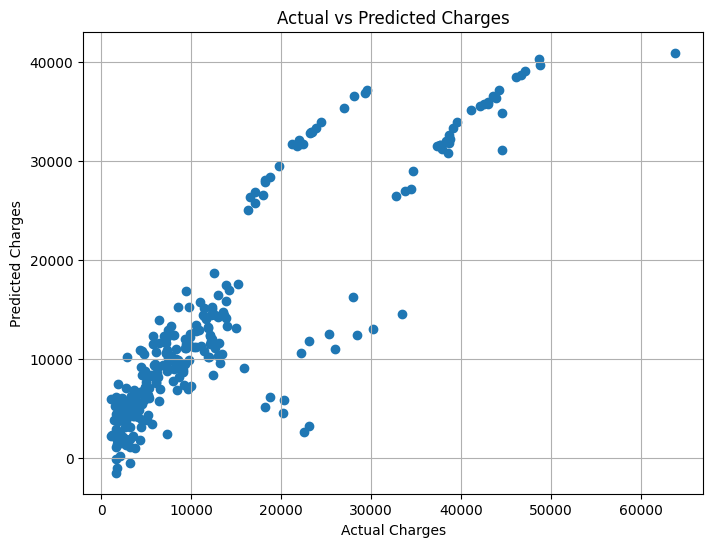

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.grid(True)
plt.show()

## Observations

1. The model predicts insurance charges reasonably well for most customers.
2. Smoking status, age, and BMI significantly influence insurance charges.
3. Some higher-cost cases are under- or over-predicted, suggesting that linear regression cannot capture all complex relationships.


##Task-5
##Conclusion

This project developed a Multiple Linear Regression model to estimate medical insurance charges using demographic and health-related features.
After preprocessing the data and encoding categorical variables, the model achieved good predictive performance based on MAE, MSE, and R² score.

Smoking status, age, and BMI emerged as the most influential factors affecting insurance costs.

The Actual vs Predicted scatter plot indicates that the model captures the overall trend well, although prediction errors increase for customers with very high charges.

A limitation of Linear Regression is its assumption of a linear relationship between the input features and the target variable, which may not adequately represent more complex real-world interactions.
